# Abstract Syntax Tree


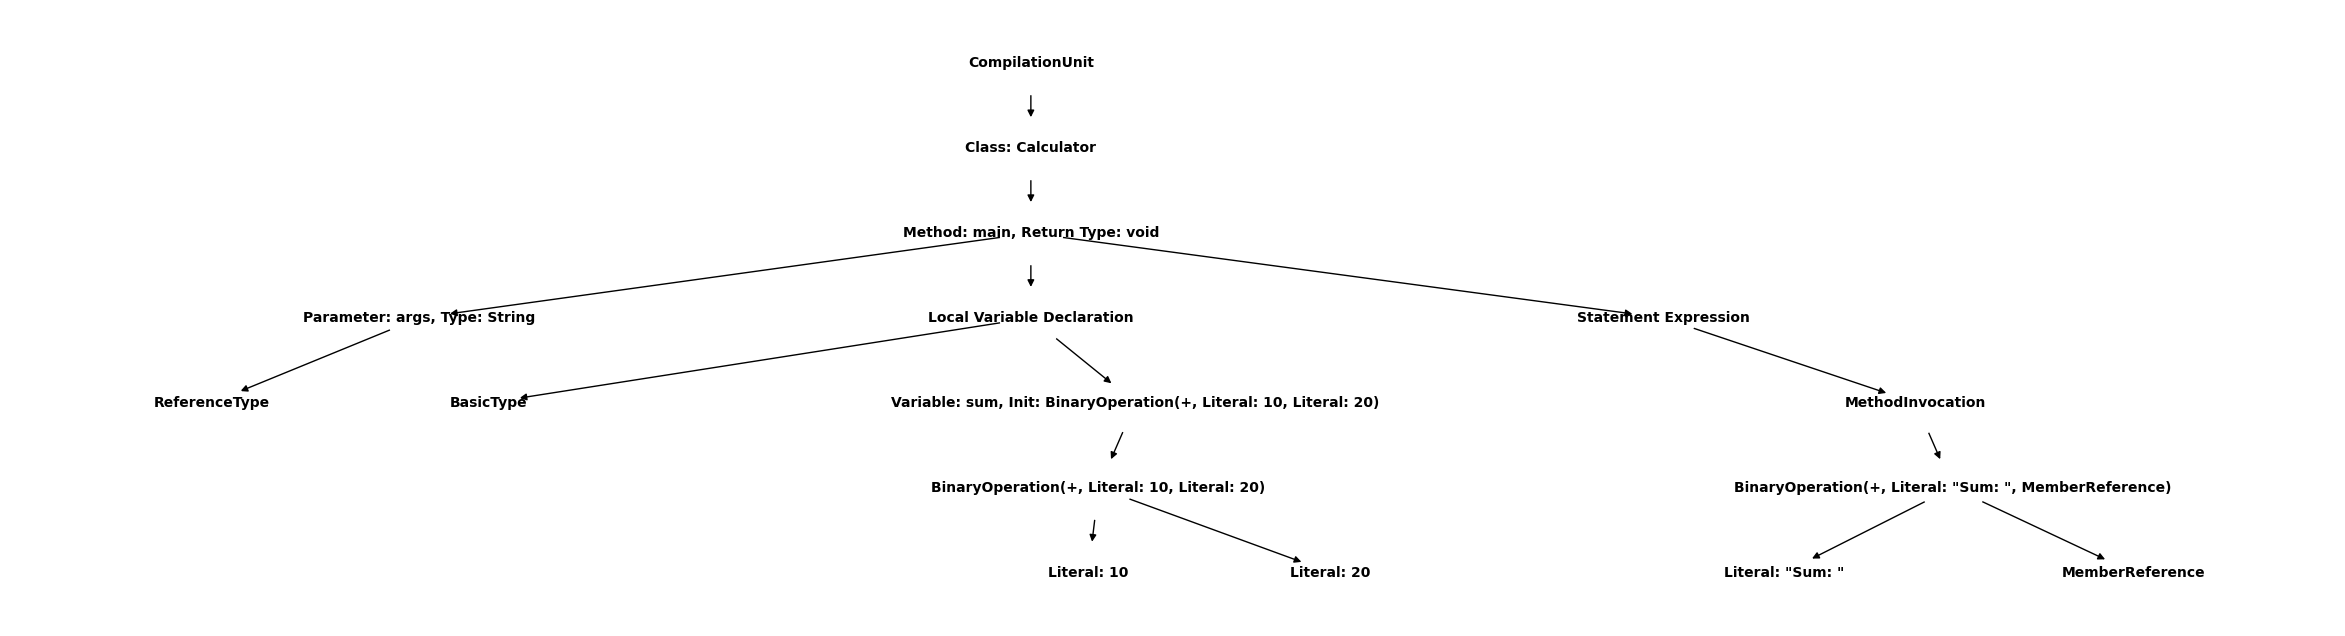

In [1]:
import javalang
import networkx as nx
import matplotlib.pyplot as plt

def java_to_ast(java_code):
    tokens = javalang.tokenizer.tokenize(java_code)
    parser = javalang.parser.Parser(tokens)
    tree = parser.parse()
    return tree

def get_node_label(node):
    if isinstance(node, javalang.tree.VariableDeclarator):
        initializer = get_node_label(node.initializer) if node.initializer else "None"
        return f"Variable: {node.name}, Init: {initializer}"
    elif isinstance(node, javalang.tree.LocalVariableDeclaration):
        return "Local Variable Declaration"
    elif isinstance(node, javalang.tree.MethodDeclaration):
        return_type = node.return_type.name if node.return_type else "void"
        return f"Method: {node.name}, Return Type: {return_type}"
    elif isinstance(node, javalang.tree.ClassDeclaration):
        return f"Class: {node.name}"
    elif isinstance(node, javalang.tree.FormalParameter):
        param_type = node.type.name if node.type else 'Unknown'
        return f"Parameter: {node.name}, Type: {param_type}"
    elif isinstance(node, javalang.tree.Literal):
        return f"Literal: {node.value}"
    elif isinstance(node, javalang.tree.BinaryOperation):
        left_operand = get_node_label(node.operandl) if node.operandl else "None"
        right_operand = get_node_label(node.operandr) if node.operandr else "None"
        return f"BinaryOperation({node.operator}, {left_operand}, {right_operand})"
    elif isinstance(node, javalang.tree.IfStatement):
        return "If Statement"
    elif isinstance(node, javalang.tree.ForStatement):
        return "For Loop"
    elif isinstance(node, javalang.tree.StatementExpression):
        return "Statement Expression"
    elif isinstance(node, javalang.tokenizer.Keyword):
        return f"Keyword: {node.value}"
    elif isinstance(node, javalang.tokenizer.Identifier):
        return f"Identifier: {node.value}"
    elif isinstance(node, javalang.tokenizer.Operator):
        return f"Operator: {node.value}"
    elif isinstance(node, javalang.tokenizer.Literal):
        return f"Literal: {node.value}"
    elif isinstance(node, javalang.tokenizer.Separator):
        return f"Delimiter: {node.value}"
    else:
        return str(type(node).__name__)

def visualize_ast(node, graph, parent=None):
    node_id = str(id(node))
    label = get_node_label(node)
    graph.add_node(node_id, label=label)

    if parent:
        graph.add_edge(parent, node_id)

    if isinstance(node, javalang.tree.Node):
        for child in node.children:
            if isinstance(child, javalang.tree.Node):
                visualize_ast(child, graph, node_id)
            elif isinstance(child, list):
                for list_item in child:
                    if isinstance(list_item, javalang.tree.Node):
                        visualize_ast(list_item, graph, node_id)

def draw_graph(graph):
    fig, ax = plt.subplots(figsize=(30, 8)) 
    pos = nx.nx_agraph.graphviz_layout(graph, prog='dot')  
    labels = nx.get_node_attributes(graph, 'label')
    nx.draw(graph, pos, labels=labels, with_labels=True, node_size=2000, node_color='white', 
            font_size=10, font_color='black', font_weight='bold', arrows=True, ax=ax)
    plt.show()

def main():
    java_code = """
    public class Calculator {
        public static void main(String[] args) {
           int sum = 10 + 20;
           System.out.println("Sum: " + sum);
        }
    }
    """
    
    ast = java_to_ast(java_code)
    graph = nx.DiGraph()
    visualize_ast(ast, graph)
    draw_graph(graph)

if __name__ == "__main__":
    main()


# Control Flow Graph

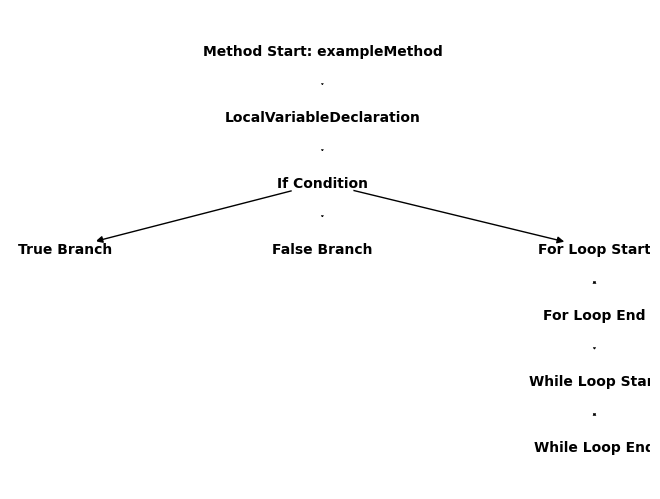

In [2]:
import javalang
import networkx as nx
import matplotlib.pyplot as plt

def java_to_ast(java_code):
    tokens = javalang.tokenizer.tokenize(java_code)
    parser = javalang.parser.Parser(tokens)
    tree = parser.parse()
    return tree

def get_statement_label(statement):
    if isinstance(statement, javalang.tree.VariableDeclarator):
        return f"Variable: {statement.name}"
    elif isinstance(statement, javalang.tree.BinaryOperation):
        return f"Binary Operation: {statement.operator}"
    elif isinstance(statement, javalang.tree.IfStatement):
        return "If Condition"
    elif isinstance(statement, javalang.tree.ForStatement):
        return "For Loop"
    elif isinstance(statement, javalang.tree.WhileStatement):
        return "While Loop"
    elif isinstance(statement, javalang.tree.MethodInvocation):
        return f"Method Call: {statement.member}"
    elif isinstance(statement, javalang.tree.Literal):
        return f"Literal: {statement.value}"
    elif isinstance(statement, javalang.tree.StatementExpression):
        return "Statement Expression"
    else:
        return type(statement).__name__  

def construct_cfg(method_node, graph, parent=None, block_id=0):
    block_label = f"Block_{block_id}"
    graph.add_node(block_label, label=f"Method Start: {method_node.name}")
    
    if parent:
        graph.add_edge(parent, block_label)
    
    current_block = block_label
    block_id += 1

    for statement in method_node.body:
        if isinstance(statement, javalang.tree.IfStatement):
            condition_block = f"Condition_{block_id}"
            true_block = f"TrueBranch_{block_id}"
            false_block = f"FalseBranch_{block_id}"
            
            graph.add_node(condition_block, label=get_statement_label(statement))
            graph.add_node(true_block, label="True Branch")
            graph.add_node(false_block, label="False Branch")
            
            graph.add_edge(current_block, condition_block)
            graph.add_edge(condition_block, true_block)
            graph.add_edge(condition_block, false_block)
            
            current_block = condition_block
            block_id += 1
        elif isinstance(statement, javalang.tree.ForStatement):
            loop_start = f"LoopStart_{block_id}"
            loop_end = f"LoopEnd_{block_id}"
            
            graph.add_node(loop_start, label="For Loop Start")
            graph.add_node(loop_end, label="For Loop End")
            
            graph.add_edge(current_block, loop_start)
            graph.add_edge(loop_start, loop_end)
            graph.add_edge(loop_end, loop_start)  
            
            current_block = loop_end
            block_id += 1
        elif isinstance(statement, javalang.tree.WhileStatement):
            while_start = f"WhileStart_{block_id}"
            while_end = f"WhileEnd_{block_id}"
            
            graph.add_node(while_start, label="While Loop Start")
            graph.add_node(while_end, label="While Loop End")
            
            graph.add_edge(current_block, while_start)
            graph.add_edge(while_start, while_end)
            graph.add_edge(while_end, while_start)  
            
            current_block = while_end
            block_id += 1
        else:
            statement_block = f"Statement_{block_id}"
            graph.add_node(statement_block, label=get_statement_label(statement))
            graph.add_edge(current_block, statement_block)
            
            current_block = statement_block
            block_id += 1

    return graph, block_id

def draw_graph(graph):
    labels = nx.get_node_attributes(graph, 'label')
    pos = nx.nx_agraph.graphviz_layout(graph, prog='dot')
    nx.draw(graph, pos, labels=labels, with_labels=True, node_size=2000, node_color='white', 
            font_size=10, font_color='black', font_weight='bold', arrows=True)
    plt.show()  

def main():
    java_code = """
    public class Example {

        public void exampleMethod() {
            int x = 10;
            if (x > 5) {
                x = x + 1;
            } else {
                x = x - 1;
            }
            for (int i = 0; i < 10; i++) {
                x = x + i;
            }
            while (x < 20) {
                x = x + 1;
                System.out.println(x);
            }
        }

    }
    """

    ast = java_to_ast(java_code)

    for path, node in ast.filter(javalang.tree.MethodDeclaration):
        graph = nx.DiGraph()
        graph, _ = construct_cfg(node, graph)
        draw_graph(graph)
        break

if __name__ == "__main__":
    main()


# Program Dependency Graph

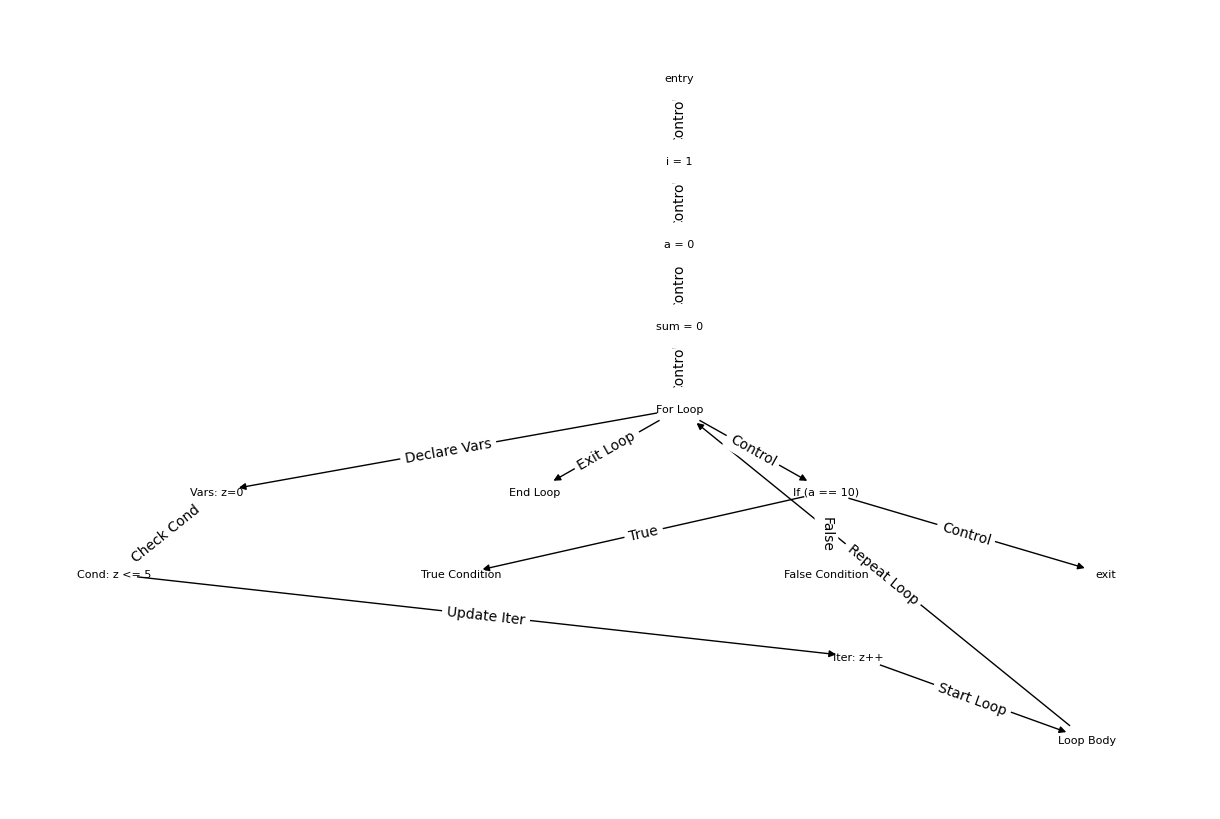

In [3]:
import javalang
import networkx as nx
import matplotlib.pyplot as plt

def java_to_ast(java_code):
    tokens = javalang.tokenizer.tokenize(java_code)
    parser = javalang.parser.Parser(tokens)
    tree = parser.parse()
    return tree

def get_variable_initial_value(declarator):
    return f"{declarator.initializer.value}" if declarator.initializer else "None"

def get_for_loop_variables(control):
    declarations = []
    processed_declarations = set()  

    if control.init:
        #print("Debugging control.init:", control.init) 

        for init_statement in control.init:

            def process_statement(statement):
                if isinstance(statement, tuple):
                    for elem in statement:
                        process_statement(elem) 
                elif isinstance(statement, javalang.tree.VariableDeclaration):
                    
                    if statement not in processed_declarations:
                        processed_declarations.add(statement)  
                        
                        for declarator in statement.declarators:
                            
                            variable_name = declarator.name
                            
                            if isinstance(declarator.initializer, javalang.tree.Literal):
                                initial_value = declarator.initializer.value
                            else:
                                initial_value = "unknown"
                            
                            declarations.append(f"{variable_name}={initial_value}")
                else:
                    statement
            
            process_statement(init_statement)

    return ', '.join(declarations) if declarations else "No variables"




def get_loop_iterators_and_terminators(control):
    iterator_block = []
    if control.update:
        for update_statement in control.update:
            if isinstance(update_statement, javalang.tree.MemberReference):
                postfix_operators = ''.join(update_statement.postfix_operators) 
                iterator_block.append(f"{update_statement.member}{postfix_operators}") 
            elif isinstance(update_statement, javalang.tree.Assignment):
                iterator_block.append(f"{update_statement.expressionl} = {update_statement.expressionr}")
            else:
                iterator_block.append(str(update_statement))
    return ', '.join(iterator_block) if iterator_block else "No iterators"

def extract_condition_expression(condition):
    if isinstance(condition, javalang.tree.BinaryOperation):
        lhs = condition.operandl
        operator = condition.operator
        rhs = condition.operandr

        lhs_text = lhs.member if isinstance(lhs, javalang.tree.MemberReference) else lhs.value if isinstance(lhs, javalang.tree.Literal) else str(lhs)
        rhs_text = rhs.member if isinstance(rhs, javalang.tree.MemberReference) else rhs.value if isinstance(rhs, javalang.tree.Literal) else str(rhs)

        return f"{lhs_text} {operator} {rhs_text}"
    return "Unknown condition"

def get_loop_condition(control):
    if control.condition:
        return extract_condition_expression(control.condition)
    return "No condition"

def construct_pdg(method_node, graph, block_id=0, data_dependencies=None):
    if data_dependencies is None:
        data_dependencies = {}

    block_label = f"S{block_id}_entry"
    graph.add_node(block_label, label="entry")
    block_id += 1

    previous_block = block_label

    for statement in method_node.body:
        if isinstance(statement, javalang.tree.IfStatement):
            condition_text = extract_condition_expression(statement.condition)
            condition_block = f"P{block_id}_if_condition"
            graph.add_node(condition_block, label=f"If ({condition_text})")
            graph.add_edge(previous_block, condition_block, label="Control")
            
            true_block = f"S{block_id}_true"
            false_block = f"S{block_id}_false"
            graph.add_node(true_block, label="True Condition")
            graph.add_node(false_block, label="False Condition")

            graph.add_edge(condition_block, true_block, label="True")
            graph.add_edge(condition_block, false_block, label="False")

            previous_block = condition_block
            block_id += 1

        elif isinstance(statement, javalang.tree.ForStatement):
            loop_variables = get_for_loop_variables(statement.control)
            loop_block = f"P{block_id}_for_loop"
            graph.add_node(loop_block, label="For Loop")
            graph.add_edge(previous_block, loop_block, label="Control")

            if loop_variables:
                variables_block = f"S{block_id}_loop_variables"
                graph.add_node(variables_block, label=f"Vars: {loop_variables}")
                graph.add_edge(loop_block, variables_block, label="Declare Vars")
                previous_block = variables_block

            loop_condition = get_loop_condition(statement.control)
            condition_block = f"S{block_id}_loop_condition"
            graph.add_node(condition_block, label=f"Cond: {loop_condition}")
            graph.add_edge(previous_block, condition_block, label="Check Cond")
            previous_block = condition_block

            loop_iterators = get_loop_iterators_and_terminators(statement.control)
            iterator_block = f"S{block_id}_loop_iterators"
            graph.add_node(iterator_block, label=f"Iter: {loop_iterators}")  # Showing j++ or similar
            graph.add_edge(previous_block, iterator_block, label="Update Iter")
            previous_block = iterator_block

            # Loop body and end of loop (Control Dependency)
            loop_body_block = f"S{block_id}_loop_body"
            end_loop_block = f"S{block_id}_end_loop"
            graph.add_node(loop_body_block, label="Loop Body")
            graph.add_node(end_loop_block, label="End Loop")

            graph.add_edge(iterator_block, loop_body_block, label="Start Loop")
            graph.add_edge(loop_body_block, loop_block, label="Repeat Loop")
            graph.add_edge(loop_block, end_loop_block, label="Exit Loop")

            previous_block = loop_block
            block_id += 1

        elif isinstance(statement, javalang.tree.LocalVariableDeclaration):
            for declarator in statement.declarators:
                var_label = f"S{block_id}_var"
                initial_value = get_variable_initial_value(declarator)
                graph.add_node(var_label, label=f"{declarator.name} = {initial_value}")
                graph.add_edge(previous_block, var_label, label="Control")
                previous_block = var_label

                if declarator.name not in data_dependencies:
                    data_dependencies[declarator.name] = var_label
                else:
                    graph.add_edge(data_dependencies[declarator.name], var_label, label="Data Dependency")
                    data_dependencies[declarator.name] = var_label
                block_id += 1

        elif isinstance(statement, javalang.tree.StatementExpression):
            if isinstance(statement.expression, javalang.tree.Assignment):
                var_label = f"S{block_id}_assignment"
                left_var = statement.expression.expressionl.member
                right_expr = statement.expression.value

                graph.add_node(var_label, label=f"{left_var} = {right_expr}")
                graph.add_edge(previous_block, var_label, label="Control")
                previous_block = var_label

                if left_var not in data_dependencies:
                    data_dependencies[left_var] = var_label
                else:
                    graph.add_edge(data_dependencies[left_var], var_label, label="Data Dependency")
                    data_dependencies[left_var] = var_label

                block_id += 1

    exit_block = f"S{block_id}_exit"
    graph.add_node(exit_block, label="exit")
    graph.add_edge(previous_block, exit_block, label="Control")

    return graph


def draw_pdg(graph):
    plt.figure(figsize=(12, 8))
    pos = nx.nx_agraph.graphviz_layout(graph, prog='dot', args='-Grankdir=TB -Gsplines=true -Gnodesep=0.5')
    labels = nx.get_node_attributes(graph, 'label')
    nx.draw(graph, pos, labels=labels, with_labels=True, node_size=1000, node_color='white', font_size=8, font_color='black')
    edge_labels = nx.get_edge_attributes(graph, 'label')
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels)
    plt.show()

def main():
    java_code = """
    public class Example {

        public void exampleMethod() {
            int i = 1;
            int a = 0;
            int sum = 0;
            for(int z=0;z<=5;z++){
                sum = sum + z;
            }
            if(a==10){
                System.out.println(10);
            }else if(a<=9){
                if(a==0){
                    System.out.println(90);
                }else{
                    System.out.println(i);
                }
            }else if(a==8){
                System.out.println(8);
            }else if(a==7){
                System.out.println(7);
            }else{
                System.out.println(0);
            }
            
            System.out.println(sum);
        }
    }
    """

    ast = java_to_ast(java_code)
    graph = nx.DiGraph()
    graph = construct_pdg(ast.types[0].methods[0], graph) 
    draw_pdg(graph)

if __name__ == "__main__":
    main()


# Code Program Graph

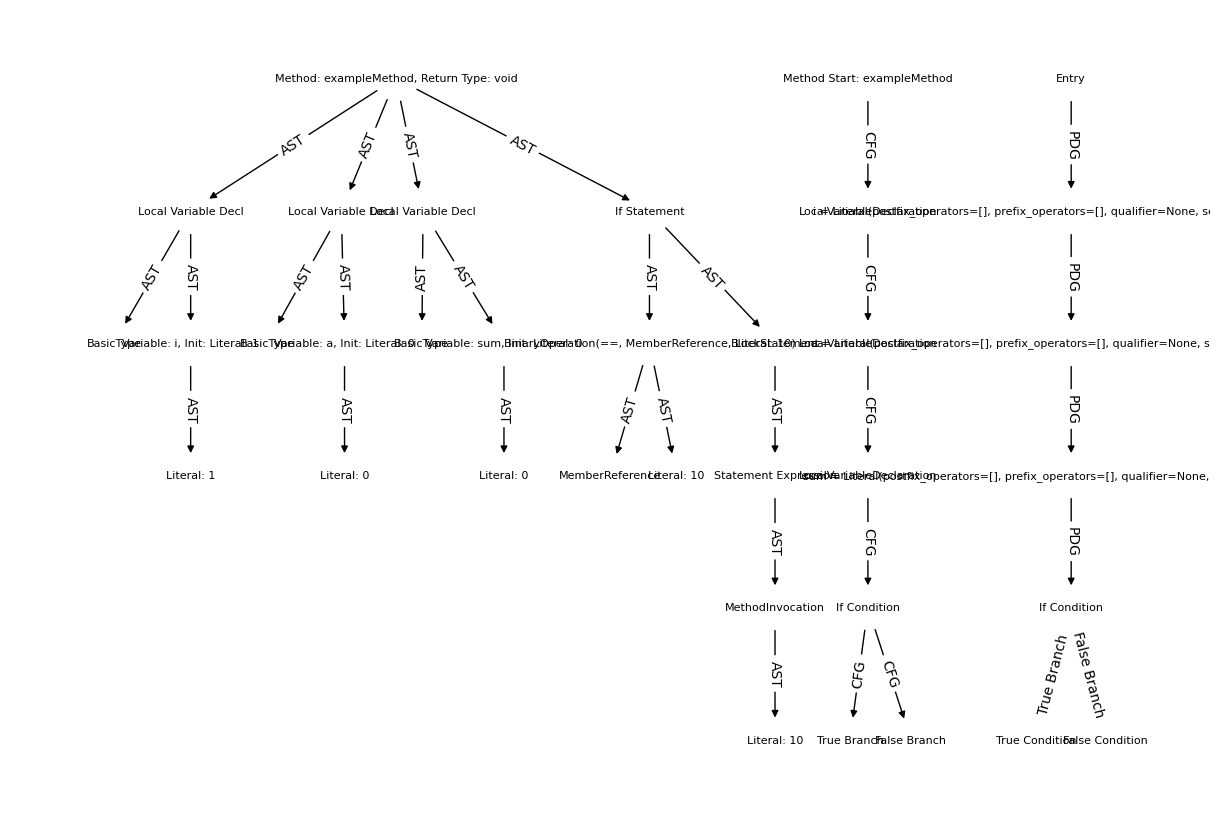

In [4]:
import javalang
import networkx as nx
import matplotlib.pyplot as plt


def java_to_ast(java_code):
    tokens = javalang.tokenizer.tokenize(java_code)
    parser = javalang.parser.Parser(tokens)
    tree = parser.parse()
    return tree

def get_node_label(node):
    if isinstance(node, javalang.tree.VariableDeclarator):
        initializer = get_node_label(node.initializer) if node.initializer else "None"
        return f"Variable: {node.name}, Init: {initializer}"
    elif isinstance(node, javalang.tree.LocalVariableDeclaration):
        return "Local Variable Decl"
    elif isinstance(node, javalang.tree.MethodDeclaration):
        return_type = node.return_type.name if node.return_type else "void"
        return f"Method: {node.name}, Return Type: {return_type}"
    elif isinstance(node, javalang.tree.ClassDeclaration):
        return f"Class: {node.name}"
    elif isinstance(node, javalang.tree.FormalParameter):
        param_type = node.type.name if node.type else 'Unknown'
        return f"Parameter: {node.name}, Type: {param_type}"
    elif isinstance(node, javalang.tree.Literal):
        return f"Literal: {node.value}"
    elif isinstance(node, javalang.tree.BinaryOperation):
        left_operand = get_node_label(node.operandl) if node.operandl else "None"
        right_operand = get_node_label(node.operandr) if node.operandr else "None"
        return f"BinaryOperation({node.operator}, {left_operand}, {right_operand})"
    elif isinstance(node, javalang.tree.IfStatement):
        return "If Statement"
    elif isinstance(node, javalang.tree.ForStatement):
        return "For Loop"
    elif isinstance(node, javalang.tree.StatementExpression):
        return "Statement Expression"
    else:
        return str(type(node).__name__)

def visualize_ast(node, graph, parent=None):
    node_id = str(id(node))
    label = get_node_label(node)
    graph.add_node(node_id, label=label)

    if parent:
        graph.add_edge(parent, node_id, label="AST")

    if isinstance(node, javalang.tree.Node):
        for child in node.children:
            if isinstance(child, javalang.tree.Node):
                visualize_ast(child, graph, node_id)
            elif isinstance(child, list):
                for list_item in child:
                    if isinstance(list_item, javalang.tree.Node):
                        visualize_ast(list_item, graph, node_id)


def get_statement_label(statement):
    if isinstance(statement, javalang.tree.VariableDeclarator):
        return f"Variable: {statement.name}"
    elif isinstance(statement, javalang.tree.BinaryOperation):
        return f"Binary Operation: {statement.operator}"
    elif isinstance(statement, javalang.tree.IfStatement):
        return "If Condition"
    elif isinstance(statement, javalang.tree.ForStatement):
        return "For Loop"
    elif isinstance(statement, javalang.tree.WhileStatement):
        return "While Loop"
    elif isinstance(statement, javalang.tree.MethodInvocation):
        return f"Method Call: {statement.member}"
    elif isinstance(statement, javalang.tree.Literal):
        return f"Literal: {statement.value}"
    elif isinstance(statement, javalang.tree.StatementExpression):
        return "Statement Expression"
    else:
        return type(statement).__name__  

def construct_cfg(method_node, graph, parent=None, block_id=0):
    block_label = f"Block_{block_id}"
    graph.add_node(block_label, label=f"Method Start: {method_node.name}")
    
    if parent:
        graph.add_edge(parent, block_label, label="CFG")
    
    current_block = block_label
    block_id += 1

    for statement in method_node.body:
        if isinstance(statement, javalang.tree.IfStatement):
            condition_block = f"Condition_{block_id}"
            true_block = f"TrueBranch_{block_id}"
            false_block = f"FalseBranch_{block_id}"
            
            graph.add_node(condition_block, label=get_statement_label(statement))
            graph.add_node(true_block, label="True Branch")
            graph.add_node(false_block, label="False Branch")
            
            graph.add_edge(current_block, condition_block, label="CFG")
            graph.add_edge(condition_block, true_block, label="CFG")
            graph.add_edge(condition_block, false_block, label="CFG")
            
            current_block = condition_block
            block_id += 1
        elif isinstance(statement, javalang.tree.ForStatement):
            loop_start = f"LoopStart_{block_id}"
            loop_end = f"LoopEnd_{block_id}"
            
            graph.add_node(loop_start, label="For Loop Start")
            graph.add_node(loop_end, label="For Loop End")
            
            graph.add_edge(current_block, loop_start, label="CFG")
            graph.add_edge(loop_start, loop_end, label="CFG")
            graph.add_edge(loop_end, loop_start, label="CFG")  
            
            current_block = loop_end
            block_id += 1
        else:
            statement_block = f"Statement_{block_id}"
            graph.add_node(statement_block, label=get_statement_label(statement))
            graph.add_edge(current_block, statement_block, label="CFG")
            
            current_block = statement_block
            block_id += 1

    return graph, block_id


def construct_pdg(method_node, graph, block_id=0, data_dependencies=None):
    if data_dependencies is None:
        data_dependencies = {}

    block_label = f"S{block_id}_entry"
    graph.add_node(block_label, label="Entry")
    block_id += 1

    previous_block = block_label

    for statement in method_node.body:
        if isinstance(statement, javalang.tree.IfStatement):
            condition_block = f"P{block_id}_if_condition"
            graph.add_node(condition_block, label="If Condition")
            graph.add_edge(previous_block, condition_block, label="PDG")
            
            true_block = f"S{block_id}_true"
            false_block = f"S{block_id}_false"
            graph.add_node(true_block, label="True Condition")
            graph.add_node(false_block, label="False Condition")

            graph.add_edge(condition_block, true_block, label="True Branch")
            graph.add_edge(condition_block, false_block, label="False Branch")

            previous_block = condition_block
            block_id += 1

        elif isinstance(statement, javalang.tree.ForStatement):
            loop_block = f"P{block_id}_for_loop"
            graph.add_node(loop_block, label="For Loop")
            graph.add_edge(previous_block, loop_block, label="PDG")
            previous_block = loop_block
            block_id += 1

        elif isinstance(statement, javalang.tree.LocalVariableDeclaration):
            for declarator in statement.declarators:
                var_label = f"S{block_id}_var"
                graph.add_node(var_label, label=f"{declarator.name} = {declarator.initializer}")
                graph.add_edge(previous_block, var_label, label="PDG")
                previous_block = var_label
                block_id += 1

        elif isinstance(statement, javalang.tree.StatementExpression):
            if isinstance(statement.expression, javalang.tree.Assignment):
                var_label = f"S{block_id}_assignment"
                graph.add_node(var_label, label=f"Assign: {statement.expression.expressionl.member}")
                graph.add_edge(previous_block, var_label, label="PDG")
                previous_block = var_label
                block_id += 1

    return graph


def construct_cpg(ast):
    graph = nx.DiGraph()

    for path, node in ast.filter(javalang.tree.MethodDeclaration):
        visualize_ast(node, graph) 
        graph, _ = construct_cfg(node, graph)  
        graph = construct_pdg(node, graph)  
        break  

    return graph


def draw_cpg(graph):
    plt.figure(figsize=(12, 8))
    pos = nx.nx_agraph.graphviz_layout(graph, prog='dot', args='-Grankdir=TB -Gsplines=true -Gnodesep=0.5')
    labels = nx.get_node_attributes(graph, 'label')
    nx.draw(graph, pos, labels=labels, with_labels=True, node_size=1000, node_color='white', font_size=8, font_color='black')
    edge_labels = nx.get_edge_attributes(graph, 'label')
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels)
    plt.show()


java_code = """
    public class Example {

        public void exampleMethod() {
            int i = 1;
            int a = 0;
            int sum = 0;
           
            if(a==10){
                System.out.println(10);
            }
        }
    }
    """

ast_tree = java_to_ast(java_code)

cpg = construct_cpg(ast_tree)
draw_cpg(cpg)


# Code Summarization

In [6]:
import javalang
import networkx as nx
from collections import defaultdict

class JavaCodeAnalyzer:
    def __init__(self, java_code):
        self.java_code = java_code
        self.ast = self._parse_code()
        self.summary = {
            'classes': [],
            'methods': [],
            'variables': defaultdict(list),
            'control_flow': defaultdict(int),
            'method_complexities': {},
            'data_dependencies': defaultdict(list),
            'method_calls': defaultdict(list),
            'loops': [],
            'conditions': []
        }

    def _parse_code(self):
        """Parse Java code into AST"""
        try:
            tree = javalang.parse.parse(self.java_code)
            return tree
        except Exception as e:
            print(f"Parsing error: {e}")
            return None

    def _analyze_variable(self, node, scope='global'):
        """Analyze variable declarations and usage"""
        if isinstance(node, javalang.tree.LocalVariableDeclaration):
            for declarator in node.declarators:
                var_info = {
                    'name': declarator.name,
                    'type': node.type.name,
                    'scope': scope,
                    'initial_value': self._get_initializer_value(declarator.initializer)
                }
                self.summary['variables'][scope].append(var_info)

    def _get_initializer_value(self, initializer):
        """Extract initializer value from variable declaration"""
        if initializer is None:
            return None
        elif isinstance(initializer, javalang.tree.Literal):
            return initializer.value
        elif isinstance(initializer, javalang.tree.BinaryOperation):
            return f"{self._get_initializer_value(initializer.operandl)} {initializer.operator} {self._get_initializer_value(initializer.operandr)}"
        elif isinstance(initializer, javalang.tree.MemberReference):
            return initializer.member
        return str(initializer)

    def _analyze_control_flow(self, node, method_name):
        """Analyze control flow structures"""
        if isinstance(node, javalang.tree.IfStatement):
            self.summary['control_flow']['if_statements'] += 1
            condition = self._extract_condition(node.condition)
            self.summary['conditions'].append({
                'type': 'if',
                'condition': condition,
                'method': method_name
            })
        elif isinstance(node, javalang.tree.ForStatement):
            self.summary['control_flow']['for_loops'] += 1
            loop_info = self._analyze_loop(node, 'for', method_name)
            self.summary['loops'].append(loop_info)
        elif isinstance(node, javalang.tree.WhileStatement):
            self.summary['control_flow']['while_loops'] += 1
            loop_info = self._analyze_loop(node, 'while', method_name)
            self.summary['loops'].append(loop_info)

    def _extract_condition(self, condition):
        """Extract condition details from control structures"""
        if isinstance(condition, javalang.tree.BinaryOperation):
            left = self._get_initializer_value(condition.operandl)
            right = self._get_initializer_value(condition.operandr)
            return f"{left} {condition.operator} {right}"
        return str(condition)

    def _analyze_loop(self, node, loop_type, method_name):
        """Analyze loop structures"""
        loop_info = {
            'type': loop_type,
            'method': method_name,
            'condition': None,
            'initialization': None,
            'update': None
        }

        if loop_type == 'for' and hasattr(node.control, 'init'):
            loop_info['initialization'] = self._extract_loop_init(node.control.init)
            loop_info['condition'] = self._extract_condition(node.control.condition)
            loop_info['update'] = self._extract_loop_update(node.control.update)
        elif loop_type == 'while':
            loop_info['condition'] = self._extract_condition(node.condition)

        return loop_info

    def _extract_loop_init(self, init):
        """Extract loop initialization details"""
        if not init:
            return None
        inits = []
        for stmt in init:
            if isinstance(stmt, javalang.tree.LocalVariableDeclaration):
                for declarator in stmt.declarators:
                    inits.append(f"{stmt.type.name} {declarator.name} = {self._get_initializer_value(declarator.initializer)}")
        return '; '.join(inits)

    def _extract_loop_update(self, update):
        updates = []
        for stmt in update:
            if isinstance(stmt, javalang.tree.Assignment):
                # Handle standard assignments like i = i + 1
                updates.append(f"{stmt.expressionl.member} {stmt.operator} {stmt.value.value}")
            elif isinstance(stmt, javalang.tree.MemberReference):
                # Check if it's an increment or decrement operation
                operator = getattr(stmt, 'postfix_operators', None) or getattr(stmt, 'prefix_operators', None)
                if operator:
                    updates.append(f"{stmt.member}{operator[0]}")
                else:
                    updates.append(f"{stmt.member}")
            else:
                updates.append(str(stmt))
            return ', '.join(updates)

    def _analyze_method_complexity(self, method_node):
        """Calculate method complexity"""
        complexity = 1  # Base complexity
        for path, node in method_node.filter(javalang.tree.IfStatement):
            complexity += 1
        for path, node in method_node.filter(javalang.tree.ForStatement):
            complexity += 1
        for path, node in method_node.filter(javalang.tree.WhileStatement):
            complexity += 1
        return complexity

    def analyze(self):
        """Perform comprehensive code analysis"""
        if not self.ast:
            return None

        # Analyze classes and methods
        for path, node in self.ast.filter(javalang.tree.ClassDeclaration):
            class_info = {
                'name': node.name,
                'methods': []
            }
            self.summary['classes'].append(class_info)

        # Analyze methods
        for path, node in self.ast.filter(javalang.tree.MethodDeclaration):
            method_name = node.name
            method_info = {
                'name': method_name,
                'return_type': node.return_type.name if node.return_type else 'void',
                'parameters': [f"{param.type.name} {param.name}" for param in node.parameters] if node.parameters else [],
                'complexity': self._analyze_method_complexity(node)
            }
            self.summary['methods'].append(method_info)
            self.summary['method_complexities'][method_name] = method_info['complexity']

            # Analyze method body
            if node.body:
                for statement in node.body:
                    self._analyze_variable(statement, method_name)
                    self._analyze_control_flow(statement, method_name)

        return self.summary

    def generate_summary_text(self):
        """Generate human-readable summary of the code"""
        if not self.summary:
            return "No analysis available"

        summary_text = []
        
        # Classes summary
        summary_text.append("=== Code Structure ===")
        for class_info in self.summary['classes']:
            summary_text.append(f"Class: {class_info['name']}")

        # Methods summary
        summary_text.append("\n=== Methods ===")
        for method in self.summary['methods']:
            params = ', '.join(method['parameters']) if method['parameters'] else 'none'
            summary_text.append(f"Method: {method['name']}")
            summary_text.append(f"- Return type: {method['return_type']}")
            summary_text.append(f"- Parameters: {params}")
            summary_text.append(f"- Complexity: {method['complexity']}")

        # Variables summary
        summary_text.append("\n=== Variables ===")
        for scope, vars in self.summary['variables'].items():
            if vars:
                summary_text.append(f"\nScope: {scope}")
                for var in vars:
                    summary_text.append(f"- {var['type']} {var['name']} = {var['initial_value']}")

        # Control flow summary
        summary_text.append("\n=== Control Flow ===")
        summary_text.append(f"If statements: {self.summary['control_flow']['if_statements']}")
        summary_text.append(f"For loops: {self.summary['control_flow']['for_loops']}")
        summary_text.append(f"While loops: {self.summary['control_flow']['while_loops']}")

        # Loops detail
        if self.summary['loops']:
            summary_text.append("\n=== Loop Details ===")
            for loop in self.summary['loops']:
                summary_text.append(f"\nLoop Type: {loop['type']} in method {loop['method']}")
                if loop['initialization']:
                    summary_text.append(f"- Initialization: {loop['initialization']}")
                if loop['condition']:
                    summary_text.append(f"- Condition: {loop['condition']}")
                if loop['update']:
                    summary_text.append(f"- Update: {loop['update']}")

        # Conditions detail
        if self.summary['conditions']:
            summary_text.append("\n=== Conditions ===")
            for cond in self.summary['conditions']:
                summary_text.append(f"- {cond['type'].upper()} condition in {cond['method']}: {cond['condition']}")

        return '\n'.join(summary_text)

def analyze_java_code(java_code):
    """Main function to analyze Java code"""
    analyzer = JavaCodeAnalyzer(java_code)
    analyzer.analyze()
    return analyzer.generate_summary_text()

# Example usage
if __name__ == "__main__":
    # Example complex Java code
    complex_java_code = """
    public class ComplexExample {
        private int field1;
        private String field2;

        public ComplexExample(int f1, String f2) {
            this.field1 = f1;
            this.field2 = f2;
        }

        public int calculateSum(int[] numbers) {
            int sum = 0;
            for (int i = 0; i < numbers.length; i++) {
                if (numbers[i] > 0) {
                    sum += numbers[i];
                }
            }
            return sum;
        }

        public void processData(String data) {
            int count = 0;
            while (count < 10) {
                if (data.length() > 0) {
                    if (data.startsWith("A")) {
                        System.out.println("Found A");
                    } else if (data.startsWith("B")) {
                        System.out.println("Found B");
                        break;
                    }
                }
                count++;
            }
        }

        public String complexOperation(int value) {
            String result = "";
            for (int i = 0; i < value; i++) {
                for (int j = 0; j < i; j++) {
                    if (i % 2 == 0) {
                        result += "even";
                    } else {
                        result += "odd";
                    }
                }
            }
            return result;
        }
    }
    """

    # Analyze the code
    summary = analyze_java_code(complex_java_code)
    print(summary)

=== Code Structure ===
Class: ComplexExample

=== Methods ===
Method: calculateSum
- Return type: int
- Parameters: int numbers
- Complexity: 3
Method: processData
- Return type: void
- Parameters: String data
- Complexity: 5
Method: complexOperation
- Return type: String
- Parameters: int value
- Complexity: 4

=== Variables ===

Scope: calculateSum
- int sum = 0

Scope: processData
- int count = 0

Scope: complexOperation
- String result = ""

=== Control Flow ===
If statements: 0
For loops: 2
While loops: 1

=== Loop Details ===

Loop Type: for in method calculateSum
- Condition: i < length
- Update: i++

Loop Type: while in method processData
- Condition: count < 10

Loop Type: for in method complexOperation
- Condition: i < value
- Update: i++


# code Summarization Enhanced

In [7]:
import javalang
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
import re

class EnhancedJavaAnalyzer(JavaCodeAnalyzer):
    def __init__(self, java_code):
        super().__init__(java_code)
        self.cpg = nx.MultiDiGraph()
        self.node_counter = Counter()
        self.detailed_summary = {
            **self.summary,
            'class_metrics': {},
            'method_metrics': {},
            'code_patterns': [],
            'dependencies': [],
            'inheritance': [],
            'method_relationships': [],
            'variable_usage': defaultdict(list),
            'nested_structures': [],
            'error_handling': [],
            'code_quality_metrics': {}
        }

    def _analyze_class_metrics(self, class_node):
        """Analyze detailed class metrics"""
        metrics = {
            'name': class_node.name,
            'fields': len([node for path, node in class_node.filter(javalang.tree.FieldDeclaration)]),
            'methods': len([node for path, node in class_node.filter(javalang.tree.MethodDeclaration)]),
            'constructors': len([node for path, node in class_node.filter(javalang.tree.ConstructorDeclaration)]),
            'interfaces': [impl.name for impl in class_node.implements] if hasattr(class_node, 'implements') else [],
            'superclass': class_node.extends.name if class_node.extends else None,
            'modifiers': list(class_node.modifiers),
            'inner_classes': len([node for path, node in class_node.filter(javalang.tree.ClassDeclaration) if path[:-1]])
        }
        return metrics

    def _analyze_method_metrics(self, method_node):
        """Analyze detailed method metrics"""
        metrics = {
            'name': method_node.name,
            'parameters': len(method_node.parameters) if method_node.parameters else 0,
            'return_type': str(method_node.return_type) if method_node.return_type else 'void',
            'modifiers': list(method_node.modifiers),
            'complexity': self._analyze_method_complexity(method_node),
            'lines': self._count_method_lines(method_node),
            'throws': [ex.type.name for ex in method_node.throws] if hasattr(method_node, 'throws') else [],
            'local_variables': len([node for path, node in method_node.filter(javalang.tree.LocalVariableDeclaration)]),
            'depth': self._calculate_nesting_depth(method_node)
        }
        return metrics

    def _calculate_nesting_depth(self, node):
        """Calculate maximum nesting depth"""
        max_depth = 0
        current_depth = 0
        
        for path, child in node.filter(None):
            if isinstance(child, (javalang.tree.IfStatement, javalang.tree.ForStatement, 
                                javalang.tree.WhileStatement, javalang.tree.TryStatement)):
                current_depth = len(path)
                max_depth = max(max_depth, current_depth)
        
        return max_depth

    def _analyze_code_patterns(self):
        """Identify common code patterns"""
        patterns = []
        
        # Singleton pattern detection
        for path, node in self.ast.filter(javalang.tree.ClassDeclaration):
            if self._is_singleton(node):
                patterns.append({
                    'type': 'Singleton',
                    'class': node.name,
                    'confidence': 'High'
                })

        # Builder pattern detection
        for path, node in self.ast.filter(javalang.tree.ClassDeclaration):
            if self._is_builder(node):
                patterns.append({
                    'type': 'Builder',
                    'class': node.name,
                    'confidence': 'Medium'
                })

        return patterns

    def _build_cpg(self):
        """Build Code Property Graph"""
        if not self.ast:
            return

        # Add nodes for classes
        for path, node in self.ast.filter(javalang.tree.ClassDeclaration):
            class_id = f"class_{node.name}"
            self.cpg.add_node(class_id, type='class', name=node.name, attrs=node.modifiers)

        # Add nodes for methods and their relationships
        for path, node in self.ast.filter(javalang.tree.MethodDeclaration):
            method_id = f"method_{node.name}"
            self.cpg.add_node(method_id, type='method', name=node.name, 
                            return_type=str(node.return_type), attrs=node.modifiers)
            
            # Add edge from class to method
            class_name = self._find_parent_class(path)
            if class_name:
                self.cpg.add_edge(f"class_{class_name}", method_id, type='contains')

        # Add nodes for variables and their relationships
        for path, node in self.ast.filter(javalang.tree.LocalVariableDeclaration):
            for declarator in node.declarators:
                var_id = f"var_{declarator.name}_{self.node_counter['var']}"
                self.node_counter['var'] += 1
                self.cpg.add_node(var_id, type='variable', name=declarator.name, 
                                var_type=node.type.name)
                
                # Add edge from method to variable
                method_name = self._find_parent_method(path)
                if method_name:
                    self.cpg.add_edge(f"method_{method_name}", var_id, type='declares')

        # Add control flow edges
        self._add_control_flow_edges()

    def _add_control_flow_edges(self):
        """Add control flow edges to CPG"""
        for path, node in self.ast.filter(javalang.tree.IfStatement):
            if_id = f"if_{self.node_counter['if']}"
            self.node_counter['if'] += 1
            self.cpg.add_node(if_id, type='control', subtype='if', 
                            condition=self._extract_condition(node.condition))
            
            method_name = self._find_parent_method(path)
            if method_name:
                self.cpg.add_edge(f"method_{method_name}", if_id, type='contains')

        # Similar for loops and other control structures
        for path, node in self.ast.filter(javalang.tree.ForStatement):
            for_id = f"for_{self.node_counter['for']}"
            self.node_counter['for'] += 1
            self.cpg.add_node(for_id, type='control', subtype='for')
            
            method_name = self._find_parent_method(path)
            if method_name:
                self.cpg.add_edge(f"method_{method_name}", for_id, type='contains')

    def visualize_cpg(self, output_file='cpg_visualization.png'):
        """Visualize the Code Property Graph"""
        plt.figure(figsize=(15, 10))
        
        # Create layout
        pos = nx.spring_layout(self.cpg, k=1, iterations=50)
        
        # Draw nodes with different colors based on type
        node_colors = {
            'class': '#ff7f0e',
            'method': '#1f77b4',
            'variable': '#2ca02c',
            'control': '#d62728'
        }
        
        for node_type in node_colors:
            nodes = [n for n, d in self.cpg.nodes(data=True) if d.get('type') == node_type]
            nx.draw_networkx_nodes(self.cpg, pos, nodelist=nodes, 
                                 node_color=node_colors[node_type],
                                 node_size=2000,
                                 alpha=0.6)
        
        # Draw edges
        edge_colors = {
            'contains': 'gray',
            'declares': 'blue',
            'calls': 'green',
            'uses': 'red'
        }
        
        for edge_type in edge_colors:
            edges = [(u, v) for (u, v, d) in self.cpg.edges(data=True) 
                    if d.get('type') == edge_type]
            nx.draw_networkx_edges(self.cpg, pos, edgelist=edges,
                                 edge_color=edge_colors[edge_type],
                                 alpha=0.5)
        
        # Add labels
        labels = {n: f"{d.get('name', n)}\n{d.get('type', '')}" 
                 for n, d in self.cpg.nodes(data=True)}
        nx.draw_networkx_labels(self.cpg, pos, labels, font_size=8)
        
        plt.title("Code Property Graph Visualization")
        plt.axis('off')
        plt.tight_layout()
        
        # Save the visualization
        plt.savefig(output_file, bbox_inches='tight', dpi=300)
        plt.close()

    def generate_detailed_summary(self):
        """Generate enhanced detailed summary"""
        if not self.detailed_summary:
            return "No detailed analysis available"

        summary_text = []
        
        # Class Analysis
        summary_text.append("====== Class Analysis ======")
        for class_metrics in self.detailed_summary['class_metrics'].values():
            summary_text.append(f"\nClass: {class_metrics['name']}")
            summary_text.append(f"- Fields: {class_metrics['fields']}")
            summary_text.append(f"- Methods: {class_metrics['methods']}")
            summary_text.append(f"- Constructors: {class_metrics['constructors']}")
            summary_text.append(f"- Modifiers: {', '.join(class_metrics['modifiers'])}")
            if class_metrics['superclass']:
                summary_text.append(f"- Extends: {class_metrics['superclass']}")
            if class_metrics['interfaces']:
                summary_text.append(f"- Implements: {', '.join(class_metrics['interfaces'])}")

        # Method Analysis
        summary_text.append("\n====== Method Analysis ======")
        for method_metrics in self.detailed_summary['method_metrics'].values():
            summary_text.append(f"\nMethod: {method_metrics['name']}")
            summary_text.append(f"- Return Type: {method_metrics['return_type']}")
            summary_text.append(f"- Parameters: {method_metrics['parameters']}")
            summary_text.append(f"- Complexity: {method_metrics['complexity']}")
            summary_text.append(f"- Lines: {method_metrics['lines']}")
            summary_text.append(f"- Nesting Depth: {method_metrics['depth']}")
            summary_text.append(f"- Local Variables: {method_metrics['local_variables']}")
            if method_metrics['throws']:
                summary_text.append(f"- Throws: {', '.join(method_metrics['throws'])}")

        # Code Patterns
        if self.detailed_summary['code_patterns']:
            summary_text.append("\n====== Design Patterns Detected ======")
            for pattern in self.detailed_summary['code_patterns']:
                summary_text.append(f"- {pattern['type']} pattern in class {pattern['class']}")
                summary_text.append(f"  Confidence: {pattern['confidence']}")

        # Nested Structures
        if self.detailed_summary['nested_structures']:
            summary_text.append("\n====== Nested Structures ======")
            for struct in self.detailed_summary['nested_structures']:
                summary_text.append(f"- {struct['type']} in {struct['location']}")
                summary_text.append(f"  Depth: {struct['depth']}")

        # Error Handling
        if self.detailed_summary['error_handling']:
            summary_text.append("\n====== Error Handling ======")
            for handler in self.detailed_summary['error_handling']:
                summary_text.append(f"- Try-Catch in {handler['method']}")
                summary_text.append(f"  Catches: {', '.join(handler['exceptions'])}")

        # Code Quality Metrics
        summary_text.append("\n====== Code Quality Metrics ======")
        quality_metrics = self.detailed_summary['code_quality_metrics']
        if quality_metrics:
            summary_text.append(f"- Average Method Complexity: {quality_metrics.get('avg_complexity', 'N/A')}")
            summary_text.append(f"- Maximum Nesting Depth: {quality_metrics.get('max_nesting_depth', 'N/A')}")
            summary_text.append(f"- Average Method Length: {quality_metrics.get('avg_method_length', 'N/A')} lines")
            summary_text.append(f"- Code to Comment Ratio: {quality_metrics.get('code_comment_ratio', 'N/A')}")

        return '\n'.join(summary_text)

def analyze_java_code_enhanced(java_code, output_file='cpg_visualization.png'):
    """Main function to perform enhanced Java code analysis with CPG visualization"""
    analyzer = EnhancedJavaAnalyzer(java_code)
    analyzer.analyze()
    analyzer._build_cpg()
    analyzer.visualize_cpg(output_file)
    return analyzer.generate_detailed_summary()

# Example usage
if __name__ == "__main__":
    # Example complex Java code
    complex_java_code = """
    public class ComplexExample {
        private int field1;
        private String field2;

        public ComplexExample(int f1, String f2) {
            this.field1 = f1;
            this.field2 = f2;
        }

        public int calculateSum(int[] numbers) {
            int sum = 0;
            for (int i = 0; i < numbers.length; i++) {
                if (numbers[i] > 0) {
                    sum += numbers[i];
                }
            }
            return sum;
        }

        public void processData(String data) {
            int count = 0;
            while (count < 10) {
                if (data.length() > 0) {
                    if (data.startsWith("A")) {
                        System.out.println("Found A");
                    } else if (data.startsWith("B")) {
                        System.out.println("Found B");
                        break;
                    }
                }
                count++;
            }
        }

        public String complexOperation(int value) {
            String result = "";
            for (int i = 0; i < value; i++) {
                for (int j = 0; j < i; j++) {
                    if (i % 2 == 0) {
                        result += "even";
                    } else {
                        result += "odd";
                    }
                }
            }
            return result;
        }
    }
    """

    # Analyze the code
    summary = analyze_java_code(complex_java_code)
    print(summary)

=== Code Structure ===
Class: ComplexExample

=== Methods ===
Method: calculateSum
- Return type: int
- Parameters: int numbers
- Complexity: 3
Method: processData
- Return type: void
- Parameters: String data
- Complexity: 5
Method: complexOperation
- Return type: String
- Parameters: int value
- Complexity: 4

=== Variables ===

Scope: calculateSum
- int sum = 0

Scope: processData
- int count = 0

Scope: complexOperation
- String result = ""

=== Control Flow ===
If statements: 0
For loops: 2
While loops: 1

=== Loop Details ===

Loop Type: for in method calculateSum
- Condition: i < length
- Update: i++

Loop Type: while in method processData
- Condition: count < 10

Loop Type: for in method complexOperation
- Condition: i < value
- Update: i++


# Code Summarization 3

In [8]:
import ast
import networkx as nx
import matplotlib.pyplot as plt

# Function to generate the AST summary
def ast_summary(node):
    summary = []

    def visit_node(node, depth=0):
        if isinstance(node, ast.FunctionDef):
            summary.append(f"{'  ' * depth}Function: {node.name}")
        elif isinstance(node, ast.Assign):
            targets = [t.id for t in node.targets if isinstance(t, ast.Name)]
            value = ast.dump(node.value)
            summary.append(f"{'  ' * depth}Assign: {targets} = {value}")
        elif isinstance(node, ast.While):
            summary.append(f"{'  ' * depth}While loop")
        elif isinstance(node, ast.If):
            summary.append(f"{'  ' * depth}If statement")
        for child in ast.iter_child_nodes(node):
            visit_node(child, depth + 1)

    visit_node(node)
    return "\n".join(summary)

# Function to generate the CFG summary
def cfg_summary():
    cfg = nx.DiGraph()
    cfg.add_edges_from([
        ("main", "sort"),
        ("sort", "merge"),
        ("merge", "sort")
    ])
    return f"CFG Summary:\nControl flows between nodes: {list(cfg.nodes)}"

# Function to generate the PDG summary
def pdg_summary():
    pdg = nx.DiGraph()
    pdg.add_edges_from([
        ("n1", "L[]"), 
        ("n2", "R[]"), 
        ("L[]", "a[]"), 
        ("R[]", "a[]"),
        ("a[]", "merge")
    ])
    return f"PDG Summary:\nData dependencies: {list(pdg.edges)}"

# Translate the provided Python code into AST
source_code = """
def merge(a, l, m, r):
    n1 = m - l + 1
    n2 = r - m
    L = a[l:l+n1]
    R = a[m+1:m+1+n2]
    i, j, k = 0, 0, l
    while i < n1 and j < n2:
        if L[i] <= R[j]:
            a[k] = L[i]
            i += 1
        else:
            a[k] = R[j]
            j += 1
        k += 1
    while i < n1:
        a[k] = L[i]
        i += 1
        k += 1
    while j < n2:
        a[k] = R[j]
        j += 1
        k += 1

def sort(a, l, r):
    if l < r:
        m = (l + r) // 2
        sort(a, l, m)
        sort(a, m + 1, r)
        merge(a, l, m, r)

a = [12, 11, 13, 5, 6, 7]
sort(a, 0, len(a) - 1)
"""

# Parse the source code into an AST
parsed_ast = ast.parse(source_code)

# Generate summaries based on AST, CFG, and PDG
ast_representation = ast_summary(parsed_ast)
cfg_representation = cfg_summary()
pdg_representation = pdg_summary()

# Print the summaries
print("AST Summary:")
print(ast_representation)
print("\n" + cfg_representation)
print("\n" + pdg_representation)



AST Summary:
  Function: merge
    Assign: ['n1'] = BinOp(left=BinOp(left=Name(id='m', ctx=Load()), op=Sub(), right=Name(id='l', ctx=Load())), op=Add(), right=Constant(value=1))
    Assign: ['n2'] = BinOp(left=Name(id='r', ctx=Load()), op=Sub(), right=Name(id='m', ctx=Load()))
    Assign: ['L'] = Subscript(value=Name(id='a', ctx=Load()), slice=Slice(lower=Name(id='l', ctx=Load()), upper=BinOp(left=Name(id='l', ctx=Load()), op=Add(), right=Name(id='n1', ctx=Load()))), ctx=Load())
    Assign: ['R'] = Subscript(value=Name(id='a', ctx=Load()), slice=Slice(lower=BinOp(left=Name(id='m', ctx=Load()), op=Add(), right=Constant(value=1)), upper=BinOp(left=BinOp(left=Name(id='m', ctx=Load()), op=Add(), right=Constant(value=1)), op=Add(), right=Name(id='n2', ctx=Load()))), ctx=Load())
    Assign: [] = Tuple(elts=[Constant(value=0), Constant(value=0), Name(id='l', ctx=Load())], ctx=Load())
    While loop
      If statement
        Assign: [] = Subscript(value=Name(id='L', ctx=Load()), slice=Name(id

In [1]:
import javalang

# Sample Java code for Merge Sort
java_code = """
public class MergeSort {

    public void mergeSort(int[] array, int left, int right) {
        if (left < right) {
            int mid = left + (right - left) / 2;

            mergeSort(array, left, mid);
            mergeSort(array, mid + 1, right);
            merge(array, left, mid, right);
        }
    }

    public void merge(int[] array, int left, int mid, int right) {
        int n1 = mid - left + 1;
        int n2 = right - mid;

        int[] L = new int[n1];
        int[] R = new int[n2];

        for (int i = 0; i < n1; i++) {
            L[i] = array[left + i];
        }
        for (int j = 0; j < n2; j++) {
            R[j] = array[mid + 1 + j];
        }

        int i = 0, j = 0;
        int k = left;
        while (i < n1 && j < n2) {
            if (L[i] <= R[j]) {
                array[k] = L[i];
                i++;
            } else {
                array[k] = R[j];
                j++;
            }
            k++;
        }

        while (i < n1) {
            array[k] = L[i];
            i++;
            k++;
        }

        while (j < n2) {
            array[k] = R[j];
            j++;
            k++;
        }
    }
}
"""

# Parse the Java code
tree = javalang.parse.parse(java_code)

# Function to generate a detailed word summarization
def generate_detailed_summary(node):
    summary = []
    if isinstance(node, javalang.tree.ClassDeclaration):
        summary.append(f"Class: {node.name}")
        summary.append("This class implements the Merge Sort algorithm, which is a divide-and-conquer sorting technique.")
        for method in node.methods:
            summary.append(f"\nMethod: {method.name}")
            summary.append(f"  - Return Type: {method.return_type}")
            summary.append(f"  - Parameters: {', '.join(f'{param.type} {param.name}' for param in method.parameters)}")
            summary.append(f"  - Description: This method {'recursively sorts the array' if method.name == 'mergeSort' else 'merges two sorted halves of the array'}.")
            if method.name == 'mergeSort':
                summary.append("  - Complexity: O(n log n) on average, where n is the number of elements in the array.")
                summary.append("  - It divides the array into halves until the base case is reached.")
            elif method.name == 'merge':
                summary.append("  - Complexity: O(n) as it merges two sorted subarrays into one sorted array.")
                summary.append("  - It combines two temporary arrays into the original array in sorted order.")
    return "\n".join(summary)

# Generate detailed summary
detailed_summary = generate_detailed_summary(tree.types[0])
print(detailed_summary)


Class: MergeSort
This class implements the Merge Sort algorithm, which is a divide-and-conquer sorting technique.

Method: mergeSort
  - Return Type: None
  - Parameters: BasicType(dimensions=[None], name=int) array, BasicType(dimensions=[], name=int) left, BasicType(dimensions=[], name=int) right
  - Description: This method recursively sorts the array.
  - Complexity: O(n log n) on average, where n is the number of elements in the array.
  - It divides the array into halves until the base case is reached.

Method: merge
  - Return Type: None
  - Parameters: BasicType(dimensions=[None], name=int) array, BasicType(dimensions=[], name=int) left, BasicType(dimensions=[], name=int) mid, BasicType(dimensions=[], name=int) right
  - Description: This method merges two sorted halves of the array.
  - Complexity: O(n) as it merges two sorted subarrays into one sorted array.
  - It combines two temporary arrays into the original array in sorted order.


=== AST Summary ===
Class: MergeSort

Method: mergeSort
  - Return Type: None
  - Parameters: BasicType(dimensions=[None], name=int) array, BasicType(dimensions=[], name=int) left, BasicType(dimensions=[], name=int) right
  - Description: This method recursively sorts the array.

Method: merge
  - Return Type: None
  - Parameters: BasicType(dimensions=[None], name=int) array, BasicType(dimensions=[], name=int) left, BasicType(dimensions=[], name=int) mid, BasicType(dimensions=[], name=int) right
  - Description: This method merges two sorted halves of the array.

=== Control Flow Graph (CFG) ===


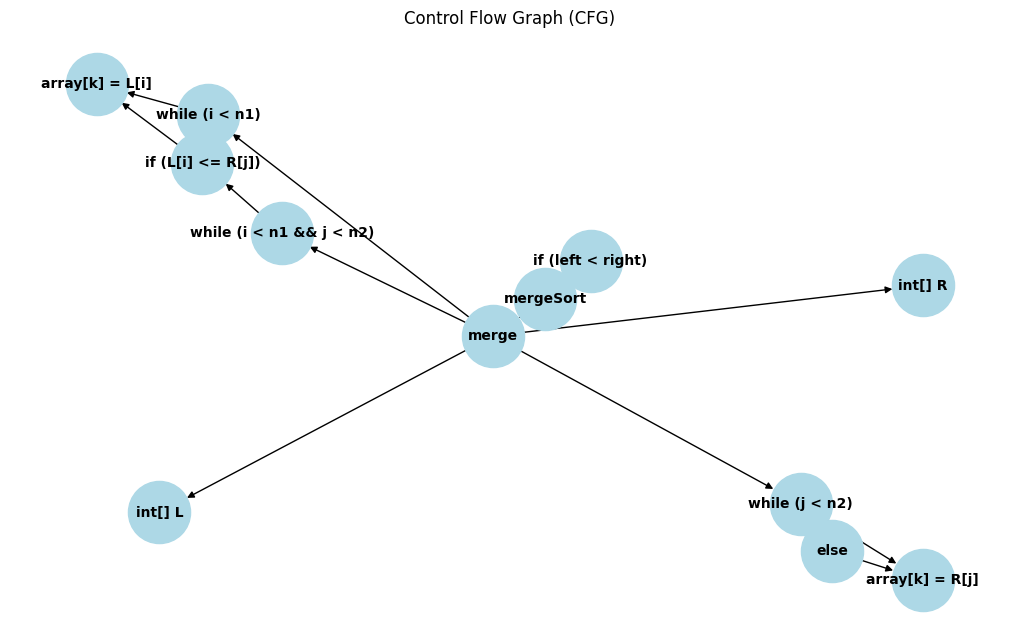


=== Program Dependency Graph (PDG) ===


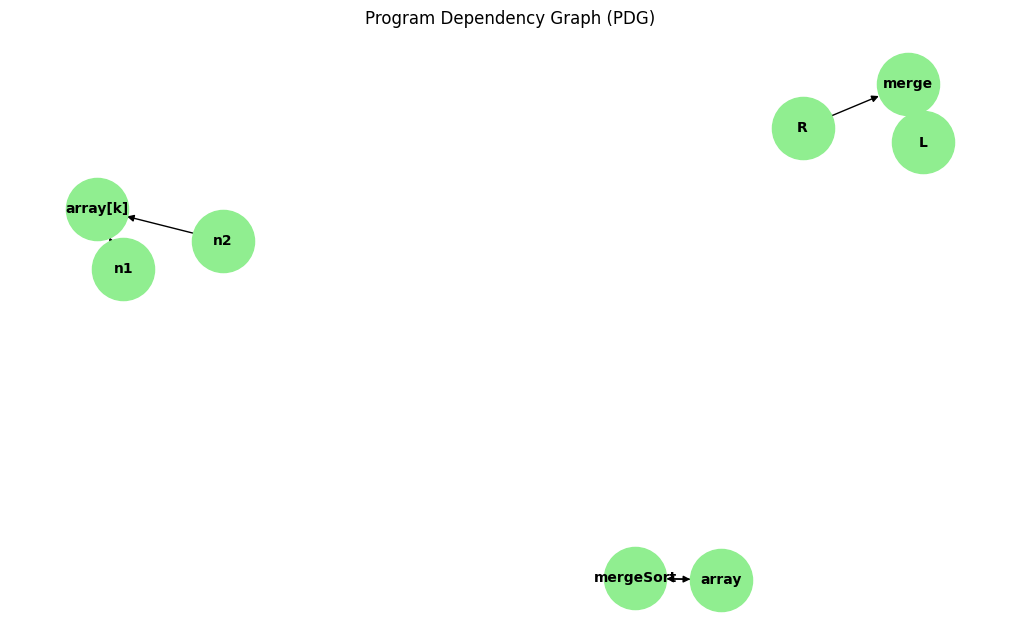


=== Code Property Graph (CPG) ===


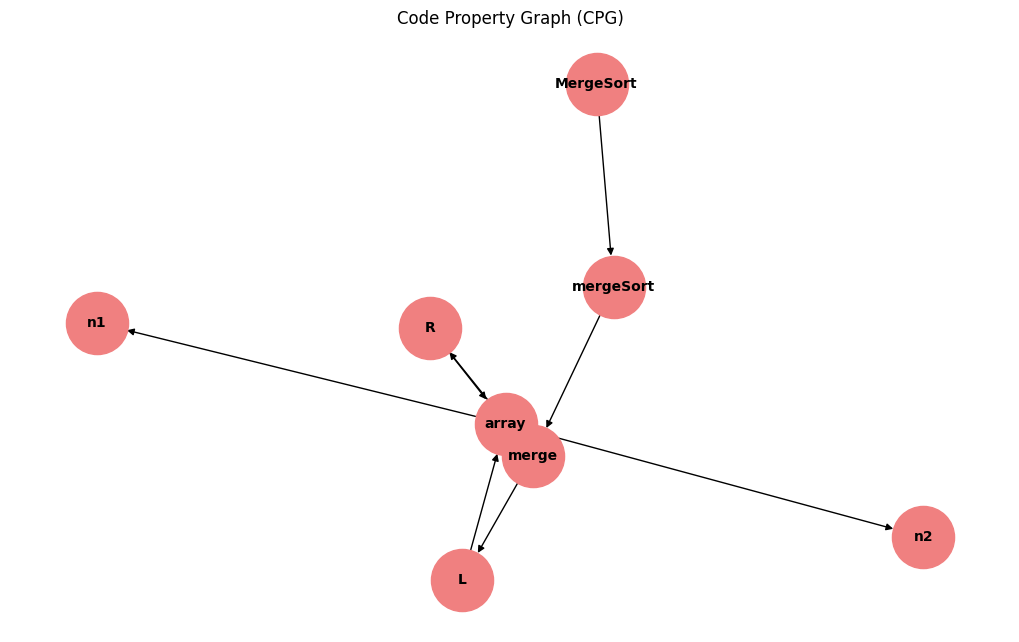

In [2]:
import javalang
import networkx as nx
import matplotlib.pyplot as plt

# Sample Java code for Merge Sort
java_code = """
public class MergeSort {

    public void mergeSort(int[] array, int left, int right) {
        if (left < right) {
            int mid = left + (right - left) / 2;

            mergeSort(array, left, mid);
            mergeSort(array, mid + 1, right);
            merge(array, left, mid, right);
        }
    }

    public void merge(int[] array, int left, int mid, int right) {
        int n1 = mid - left + 1;
        int n2 = right - mid;

        int[] L = new int[n1];
        int[] R = new int[n2];

        for (int i = 0; i < n1; i++) {
            L[i] = array[left + i];
        }
        for (int j = 0; j < n2; j++) {
            R[j] = array[mid + 1 + j];
        }

        int i = 0, j = 0;
        int k = left;
        while (i < n1 && j < n2) {
            if (L[i] <= R[j]) {
                array[k] = L[i];
                i++;
            } else {
                array[k] = R[j];
                j++;
            }
            k++;
        }

        while (i < n1) {
            array[k] = L[i];
            i++;
            k++;
        }

        while (j < n2) {
            array[k] = R[j];
            j++;
            k++;
        }
    }
}
"""

# Parse the Java code
tree = javalang.parse.parse(java_code)

# Function to generate a detailed AST summary
def generate_ast_summary(node):
    summary = []
    if isinstance(node, javalang.tree.ClassDeclaration):
        summary.append(f"Class: {node.name}")
        for method in node.methods:
            summary.append(f"\nMethod: {method.name}")
            summary.append(f"  - Return Type: {method.return_type}")
            summary.append(f"  - Parameters: {', '.join(f'{param.type} {param.name}' for param in method.parameters)}")
            summary.append(f"  - Description: This method {'recursively sorts the array' if method.name == 'mergeSort' else 'merges two sorted halves of the array'}.")
    return "\n".join(summary)

# Function to generate a CFG
def generate_cfg():
    G = nx.DiGraph()

    G.add_edges_from([
        ("mergeSort", "if (left < right)"),
        ("if (left < right)", "mergeSort"),
        ("mergeSort", "merge"),
        ("merge", "int[] L"),
        ("merge", "int[] R"),
        ("merge", "while (i < n1 && j < n2)"),
        ("while (i < n1 && j < n2)", "if (L[i] <= R[j])"),
        ("if (L[i] <= R[j])", "array[k] = L[i]"),
        ("else", "array[k] = R[j]"),
        ("merge", "while (i < n1)"),
        ("while (i < n1)", "array[k] = L[i]"),
        ("merge", "while (j < n2)"),
        ("while (j < n2)", "array[k] = R[j]"),
    ])

    plt.figure(figsize=(10, 6))
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue', font_size=10, font_weight='bold', arrows=True)
    plt.title("Control Flow Graph (CFG)")
    plt.show()

# Function to generate a PDG
def generate_pdg():
    G = nx.DiGraph()

    # Nodes represent variables and method calls
    G.add_edges_from([
        ("array", "mergeSort"),
        ("mergeSort", "array"),
        ("L", "merge"),
        ("R", "merge"),
        ("n1", "array[k]"),
        ("n2", "array[k]"),
    ])

    plt.figure(figsize=(10, 6))
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightgreen', font_size=10, font_weight='bold', arrows=True)
    plt.title("Program Dependency Graph (PDG)")
    plt.show()

# Function to generate a CPG
def generate_cpg():
    G = nx.DiGraph()

    # Nodes represent various components of the program
    G.add_edges_from([
        ("MergeSort", "mergeSort"),
        ("mergeSort", "merge"),
        ("merge", "L"),
        ("merge", "R"),
        ("L", "array"),
        ("R", "array"),
        ("array", "n1"),
        ("array", "n2"),
    ])

    plt.figure(figsize=(10, 6))
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightcoral', font_size=10, font_weight='bold', arrows=True)
    plt.title("Code Property Graph (CPG)")
    plt.show()

# Generate detailed summaries and graphs
ast_summary = generate_ast_summary(tree.types[0])
print("=== AST Summary ===")
print(ast_summary)

print("\n=== Control Flow Graph (CFG) ===")
generate_cfg()

print("\n=== Program Dependency Graph (PDG) ===")
generate_pdg()

print("\n=== Code Property Graph (CPG) ===")
generate_cpg()


In [3]:
import javalang

# Sample Java code for Merge Sort
java_code = """
public class MergeSort {

    public void mergeSort(int[] array, int left, int right) {
        if (left < right) {
            int mid = left + (right - left) / 2;

            mergeSort(array, left, mid);
            mergeSort(array, mid + 1, right);
            merge(array, left, mid, right);
        }
    }

    public void merge(int[] array, int left, int mid, int right) {
        int n1 = mid - left + 1;
        int n2 = right - mid;

        int[] L = new int[n1];
        int[] R = new int[n2];

        for (int i = 0; i < n1; i++) {
            L[i] = array[left + i];
        }
        for (int j = 0; j < n2; j++) {
            R[j] = array[mid + 1 + j];
        }

        int i = 0, j = 0;
        int k = left;
        while (i < n1 && j < n2) {
            if (L[i] <= R[j]) {
                array[k] = L[i];
                i++;
            } else {
                array[k] = R[j];
                j++;
            }
            k++;
        }

        while (i < n1) {
            array[k] = L[i];
            i++;
            k++;
        }

        while (j < n2) {
            array[k] = R[j];
            j++;
            k++;
        }
    }
}
"""

# Parse the Java code
tree = javalang.parse.parse(java_code)

# Function to generate a detailed AST summary
def generate_ast_summary(node):
    summary = []
    if isinstance(node, javalang.tree.ClassDeclaration):
        summary.append(f"Class: {node.name}")
        for method in node.methods:
            summary.append(f"\nMethod: {method.name}")
            summary.append(f"  - Return Type: {method.return_type}")
            summary.append(f"  - Parameters: {', '.join(f'{param.type} {param.name}' for param in method.parameters)}")
            summary.append(f"  - Description: This method {'recursively sorts the array' if method.name == 'mergeSort' else 'merges two sorted halves of the array'}.")
    return "\n".join(summary)

# Function to generate a CFG summary
def generate_cfg_summary():
    cfg_summary = """
=== Control Flow Graph (CFG) ===
- mergeSort -> if (left < right)
- if (left < right) -> mergeSort (left, mid)
- if (left < right) -> mergeSort (mid + 1, right)
- if (left < right) -> merge(array, left, mid, right)
- merge -> L[i] = array[left + i]
- merge -> R[j] = array[mid + 1 + j]
- merge -> while (i < n1 && j < n2)
- while (i < n1 && j < n2) -> if (L[i] <= R[j])
- while (i < n1 && j < n2) -> else (array[k] = R[j])
- while (i < n1 && j < n2) -> k++
- merge -> while (i < n1)
- while (i < n1) -> array[k] = L[i]
- while (i < n1) -> k++
- merge -> while (j < n2)
- while (j < n2) -> array[k] = R[j]
- while (j < n2) -> k++
"""
    return cfg_summary.strip()

# Function to generate a PDG summary
def generate_pdg_summary():
    pdg_summary = """
=== Program Dependency Graph (PDG) ===
- array -> mergeSort
- mergeSort -> array
- L -> merge
- R -> merge
- n1 -> array[k]
- n2 -> array[k]
"""
    return pdg_summary.strip()

# Function to generate a CPG summary
def generate_cpg_summary():
    cpg_summary = """
=== Code Property Graph (CPG) ===
- MergeSort -> mergeSort
- mergeSort -> merge
- merge -> L
- merge -> R
- L -> array
- R -> array
- array -> n1
- array -> n2
"""
    return cpg_summary.strip()

# Generate detailed summaries
ast_summary = generate_ast_summary(tree.types[0])
print("=== AST Summary ===")
print(ast_summary)

print("\n" + generate_cfg_summary())
print("\n" + generate_pdg_summary())
print("\n" + generate_cpg_summary())


=== AST Summary ===
Class: MergeSort

Method: mergeSort
  - Return Type: None
  - Parameters: BasicType(dimensions=[None], name=int) array, BasicType(dimensions=[], name=int) left, BasicType(dimensions=[], name=int) right
  - Description: This method recursively sorts the array.

Method: merge
  - Return Type: None
  - Parameters: BasicType(dimensions=[None], name=int) array, BasicType(dimensions=[], name=int) left, BasicType(dimensions=[], name=int) mid, BasicType(dimensions=[], name=int) right
  - Description: This method merges two sorted halves of the array.

=== Control Flow Graph (CFG) ===
- mergeSort -> if (left < right)
- if (left < right) -> mergeSort (left, mid)
- if (left < right) -> mergeSort (mid + 1, right)
- if (left < right) -> merge(array, left, mid, right)
- merge -> L[i] = array[left + i]
- merge -> R[j] = array[mid + 1 + j]
- merge -> while (i < n1 && j < n2)
- while (i < n1 && j < n2) -> if (L[i] <= R[j])
- while (i < n1 && j < n2) -> else (array[k] = R[j])
- while